In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/Users/nidagallusandeep/Downloads/DMart.csv.zip")

In [3]:
df.head()

,Name,Brand,Price,DiscountedPrice,Category,SubCategory,Quantity,Description,BreadCrumbs
0,Premia Badam (Almonds),Premia,451.0,329.0,Grocery,Grocery/Dry Fruits,500 gm,India,Grocery > Grocery/Dry Fruits
1,Premia Badam (Almonds),Premia,109.0,85.0,Grocery,Grocery/Dry Fruits,100 gm,India,Grocery > Grocery/Dry Fruits
2,Premia Badam (Almonds),Premia,202.0,175.0,Grocery,Grocery/Dry Fruits,200 gm,India,Grocery > Grocery/Dry Fruits
3,Nutraj California Almonds (Badam),Nutraj,599.0,349.0,Grocery,Dry Fruits,500 gm,USA,Grocery > Dry Fruits
4,Nutraj California Almonds (Badam),Nutraj,1549.0,659.0,Grocery,Dry Fruits,1 kg,USA,Grocery > Dry Fruits


In [4]:
df.shape

(5189, 9)

In [5]:
print(df.dtypes)

Name                object
Brand               object
Price              float64
DiscountedPrice    float64
Category            object
SubCategory         object
Quantity            object
Description         object
BreadCrumbs         object
dtype: object


In [6]:
df["Name"].unique()

array(['Premia Badam (Almonds)', 'Nutraj California Almonds (Badam)',
       'Chana Dal', ..., 'Navneet Youva Long Notebook - Assorted',
       'Navneet Youva Drawing Book - Assorted',
       'Navneet Youva Canvas Board (10x12 Inches)'],
      shape=(4361,), dtype=object)

In [7]:
df["Name"].nunique()

4360

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5189 entries, 0 to 5188
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             5188 non-null   object 
 1   Brand            4789 non-null   object 
 2   Price            5188 non-null   float64
 3   DiscountedPrice  5188 non-null   float64
 4   Category         5186 non-null   object 
 5   SubCategory      5186 non-null   object 
 6   Quantity         5188 non-null   object 
 7   Description      5187 non-null   object 
 8   BreadCrumbs      5186 non-null   object 
dtypes: float64(2), object(7)
memory usage: 365.0+ KB


# Numerical Columns.
- Price
- DiscountedPrice
# Categorical Columns.
- Name
- Brand
- Category
- SubCategory
- Quantity
- Description
- BreadCrumbs

In [9]:
df.isnull().sum()

Name                 1
Brand              400
Price                1
DiscountedPrice      1
Category             3
SubCategory          3
Quantity             1
Description          2
BreadCrumbs          3
dtype: int64

In [10]:
round(df.isnull().sum()/len(df)*100,2)

Name               0.02
Brand              7.71
Price              0.02
DiscountedPrice    0.02
Category           0.06
SubCategory        0.06
Quantity           0.02
Description        0.04
BreadCrumbs        0.06
dtype: float64

In [11]:
df["Name"]=df["Name"].fillna(df["Name"].mode()[0])
df["Brand"]=df["Brand"].fillna(df["Brand"].mode()[0])
df["Price"]=df["Price"].fillna(df["Price"].mean())
df["DiscountedPrice"]=df["DiscountedPrice"].fillna(df["DiscountedPrice"].mode()[0])
df["Category"]=df["Category"].fillna(df["Category"].mode()[0])
df["SubCategory"]=df["SubCategory"].fillna(df["SubCategory"].mode()[0])
df["Quantity"]=df["Quantity"].fillna(df["Quantity"].mode()[0])
df["Description"]=df["Description"].fillna(df["Description"].mode()[0])
df["BreadCrumbs"]=df["BreadCrumbs"].fillna(df["BreadCrumbs"].mode()[0])

In [12]:
df.isnull().sum()

Name               0
Brand              0
Price              0
DiscountedPrice    0
Category           0
SubCategory        0
Quantity           0
Description        0
BreadCrumbs        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

# 1. Which categories have the highest average product price.

In [14]:
category_price=(
    df.groupby("Category")["Price"].mean().sort_values(ascending=False)
)

In [15]:
category_price

Category
Smartwatches                     5999.000000
Wonderchef                       5300.000000
Butterfly                        4248.500000
Pigeon                           3595.000000
Appliances                       2469.207547
Backpacks                        2188.384615
Motorbike Helmets                1110.750000
Raincoat                          937.363636
Joyo Plastics                     907.500000
Water Purifiers & Accessories     875.000000
Zebronics                         801.000000
Syska                             799.000000
Specials                          774.002674
Home & Kitchen                    476.566330
Beauty & Cosmetics                399.739130
Clothing & Accessories            372.134021
Computer Accessories              349.000000
DMart Grocery                     343.612903
Grocery                           311.383333
Personal Care                     302.208998
Geep                              288.000000
Kitchen Aprons                    285.000000
D

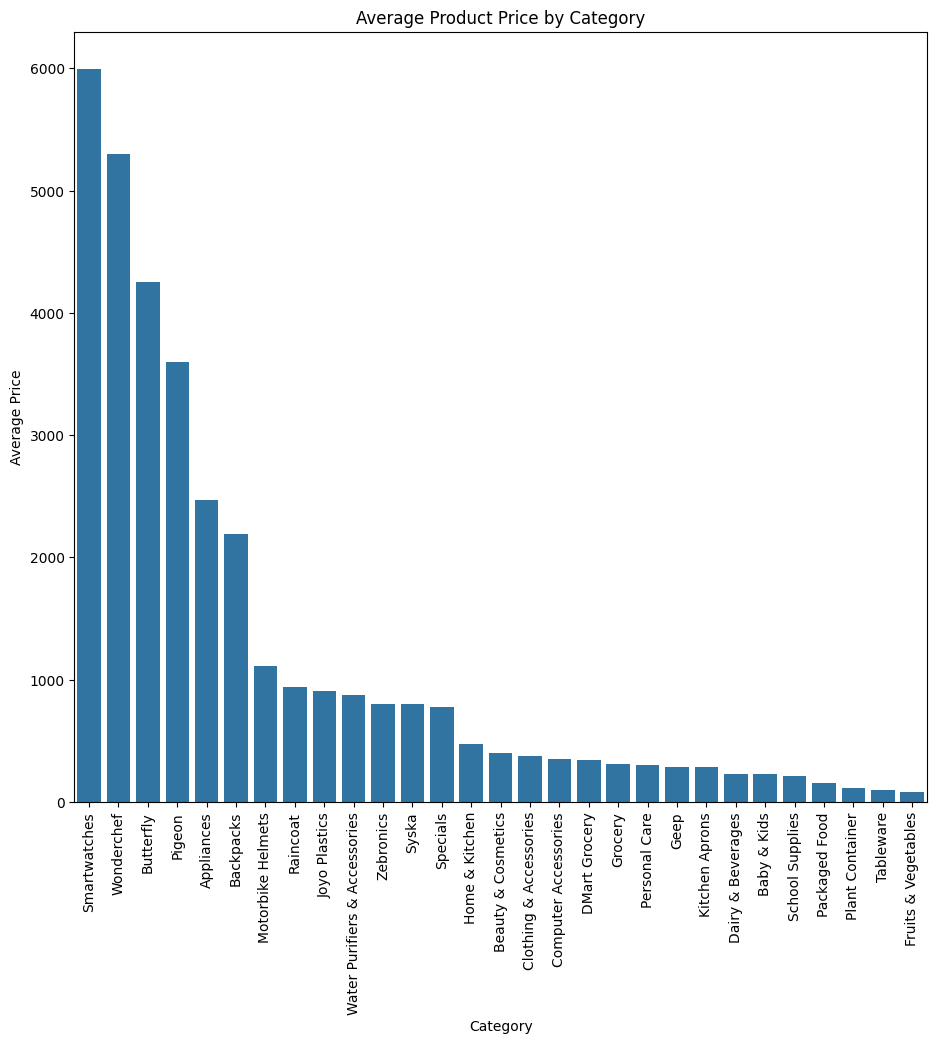

In [16]:
# plot
plt.figure(figsize=(11,10))

sns.barplot(
    x=category_price.index,
    y=category_price.values
)
plt.xticks(rotation=90)
plt.title("Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")

plt.show()

# Observation
- Smartwatches category has the highest average price (5999)
- Wonderchef and Butterfly products are also expensive
- Appliances and Backpacks have medium-high prices
- Fruits & Vegetables have the lowest average price (79)
- Grocery-related categories generally have lower prices
- Electronic and appliance categories are costlier than daily-use products

# 2.Which brands sell the most expensive products

In [17]:
brand_price=(df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10))
brand_price

Brand
Bathla             7899.000000
Morphy Richards    6095.000000
Butterfly          3975.333333
RRO Primio         3625.000000
Gulab              3589.000000
Leonardo           3349.000000
Boat               3275.714286
Bertolli           2999.000000
Wonderchef         2970.000000
VIP                2852.500000
Name: Price, dtype: float64

# Observation
- Bathla brand sells the most expensive products with an average price of around 7899
- Morphy Richards is the second highest-priced brand
- Butterfly, Wonderchef, and Boat also have high-priced products
- Most expensive brands belong to electronics and home appliances categories
- Brands like VIP and Boat maintain premium pricing

In [18]:
# average price by brand
brand_price=(df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(5))
print(brand_price)

Brand
Bathla             7899.000000
Morphy Richards    6095.000000
Butterfly          3975.333333
RRO Primio         3625.000000
Gulab              3589.000000
Name: Price, dtype: float64


# Observation
- Bathla has the highest average product price (7899)
- Morphy Richards is the second most expensive brand (6095)
- Butterfly, RRO Primio, and Gulab also sell high-priced products
- These brands mainly belong to premium appliance and household categories
- Premium brands have higher average prices compared to regular brands

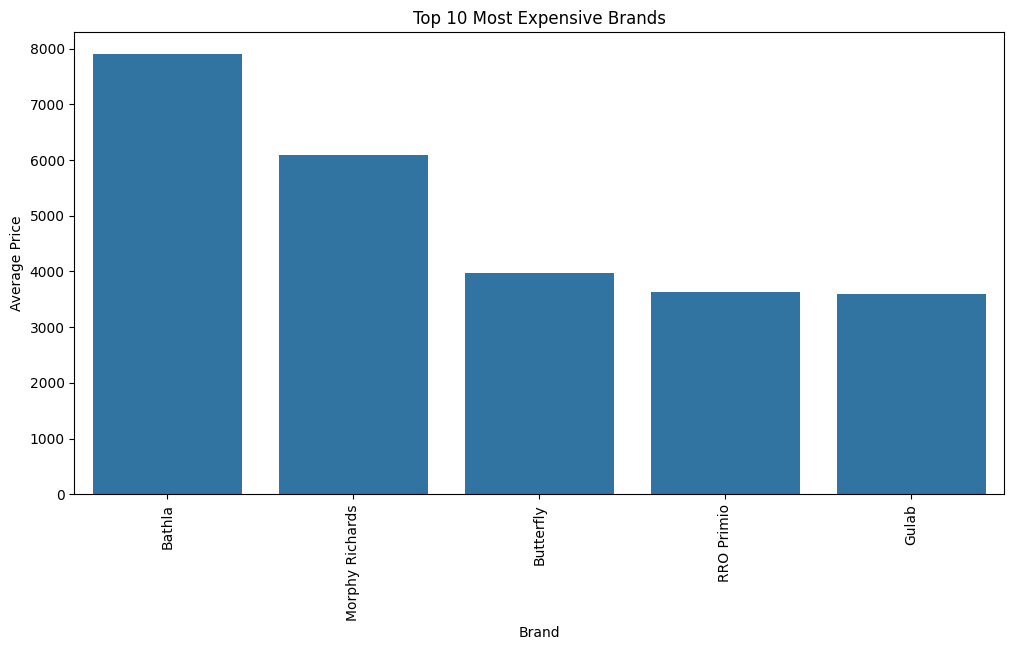

In [19]:
# plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=90)
plt.title("Top 10 Most Expensive Brands")
plt.xlabel("Brand")
plt.ylabel("Average Price")

plt.show()

# Observation
- The bar chart shows that Bathla has the highest average product price among all brands.
- Morphy Richards is the second most expensive brand.
- Butterfly, RRO Primio, and Gulab also have high average prices.
- There is a noticeable price gap between Bathla and the remaining brands.
- Premium appliance and household brands dominate the top expensive brands list

# 3. What is the price distribution of products

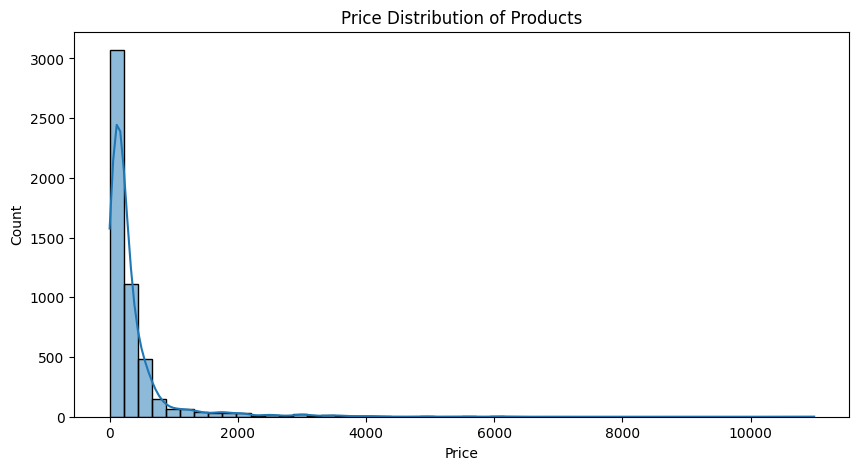

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(
    df["Price"],
    bins=50,
    kde=True)

plt.title("Price Distribution of Products")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

# Observation
- Most product prices are concentrated in the lower price range
- The distribution is right-skewed, meaning a few products have very high prices
- A large number of products are priced below 1000
- Only a small number of premium products have prices above 5000
- The dataset contains some high-price outliers

# 4. Which products have extremely high prices (outliers)?

In [21]:
product=(df.groupby("Name")["Price"].mean().sort_values(ascending=False).head(5))
print(product)

Name
Philips UV-C Disinfection System           10990.0
Bathla Advance 5 Step Ladder-Orange         8999.0
Godrej Goldilocks Personal White Locker     7669.0
Bathla Advance 4 Step Ladder-Orange         6799.0
Bajaj GX8 Mixer Grinder - 750 W             6275.0
Name: Price, dtype: float64


# Observation
- Philips UV-C Disinfection System is the most expensive product
- Bathla ladders also have very high prices
- These products are much costlier than normal products

# 5. Which categories offer the highest discounts

In [22]:
# create discount percentage column

df["DiscountPercent"] = (
    (df["Price"] - df["DiscountedPrice"]) / df["Price"]) * 100

In [23]:
# average discount by category
category_discount = (
    df.groupby("Category")["DiscountPercent"]
    .mean()
    .sort_values(ascending=False)
)

print(category_discount)

Category
Geep                             61.865712
Smartwatches                     58.343057
Butterfly                        57.467860
Zebronics                        56.750757
Backpacks                        51.732478
Pigeon                           49.958275
Wonderchef                       49.075472
Syska                            43.804756
Computer Accessories             37.614940
Joyo Plastics                    36.889328
Specials                         32.720674
Clothing & Accessories           32.361201
Appliances                       31.653101
Plant Container                  30.972572
Beauty & Cosmetics               29.153130
Home & Kitchen                   29.010845
Packaged Food                    28.679332
Personal Care                    26.025842
DMart Grocery                    24.903072
Kitchen Aprons                   24.561404
Fruits & Vegetables              22.323331
Grocery                          21.847832
Dairy & Beverages                21.408246
Ta

# Observation
- Categories at the top give the highest discounts to customers.
- Personal Care, Home & Kitchen, and Packaged Food may have higher discounts because many brands compete in these categories.
- Categories with low discounts usually have stable prices.
- High discounts help:
- attract customers
- increase sales
- clear old stock
- Low discount categories may contain essential or low-cost products.
- The graph helps understand which categories use more offers and promotions.

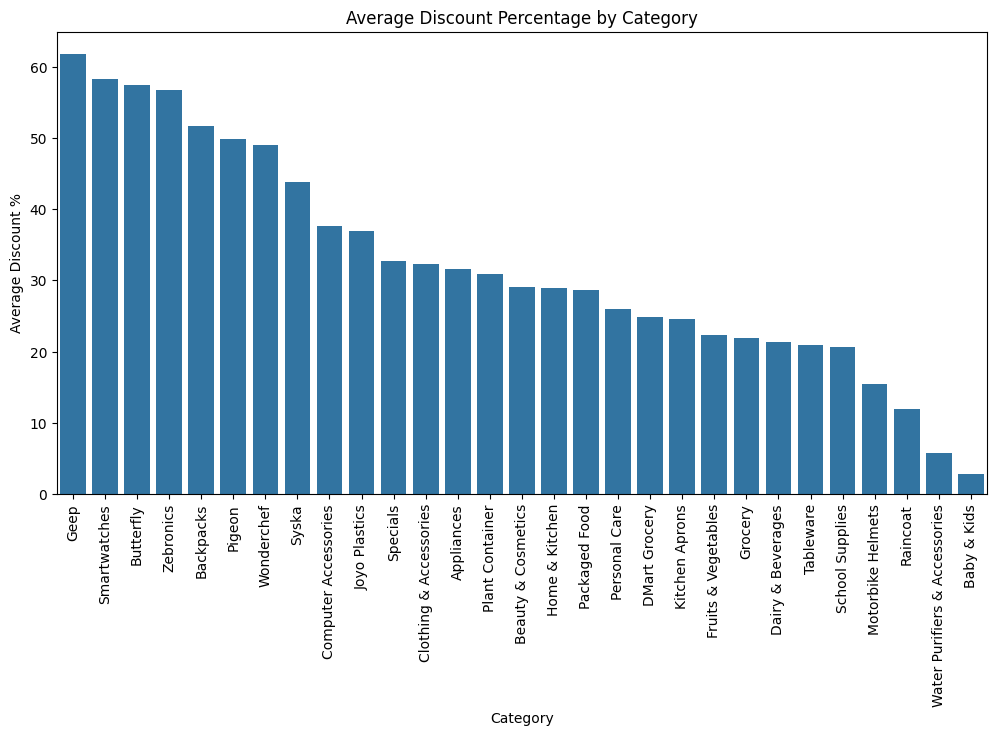

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_discount.index,
    y=category_discount.values
)

plt.xticks(rotation=90)

plt.title("Average Discount Percentage by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount %")

plt.show()

# Observation in English
- Jeep category gives the highest average discount to customers.
- Smartwatches, Butterfly, and Zebronics categories also provide high discounts.
- Categories like Grocery, Dairy & Beverages, and School Supplies give lower discounts.
- High discounts are mainly used to:
- attract more customers
- increase product sales
- clear old stock quickly
- Low discount categories usually contain essential or already low-priced products.
- This graph helps identify which categories use more offers and promotional strategies.

# 6. Which brands provide the maximum average discount?

In [25]:
df["DiscountPercent"]=((df["Price"]-df["DiscountedPrice"])/df["Price"])*100

In [26]:
# average discount by brand
brand_discount=(
    df.groupby("Brand")["DiscountPercent"].mean().sort_values(ascending=False).head(10))

In [27]:
brand_discount

Brand
Dr.WaterR     76.717812
Raymond       66.698428
Dinesmart     65.666041
Bertolli      65.021674
Paras         64.275466
VIP           64.008404
Killer        63.197026
Aristocrat    62.837209
Naagin        61.955556
Dr. WaterR    61.872910
Name: DiscountPercent, dtype: float64

# Observation
- Dr.WaterR provides the highest average discount among all brands.
- Raymond, Dinesmart, and Bertolli also offer very high discounts.
- These brands may use heavy discounts to attract more customers and increase sales.
- Brands with high discounts are likely following strong promotional strategies.
- The analysis helps identify brands that focus more on offers and customer attraction.

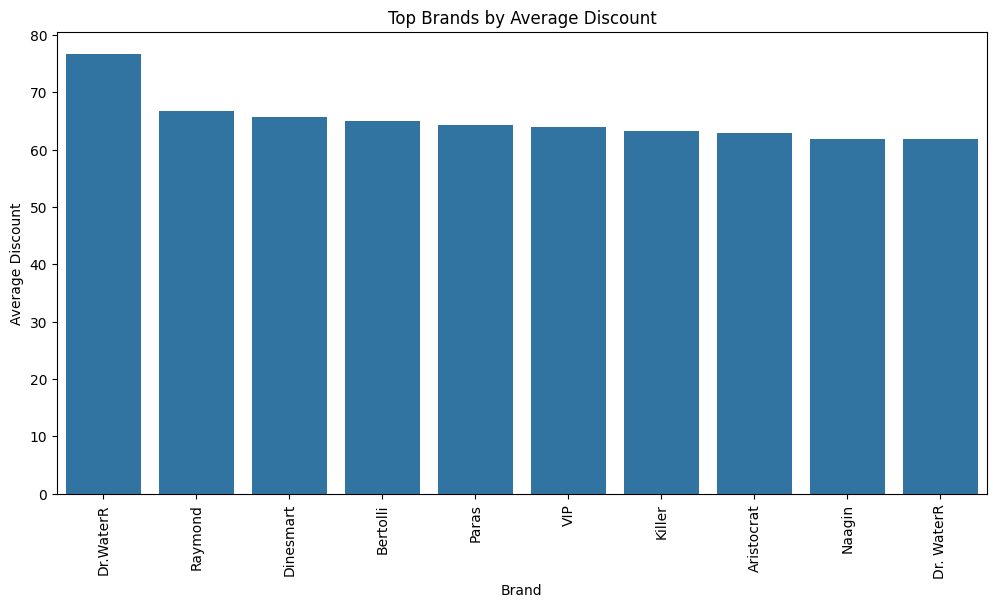

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=brand_discount.index,
    y=brand_discount.values
)
plt.xticks(rotation=90)
plt.title("Top Brands by Average Discount")
plt.xlabel("Brand")
plt.ylabel("Average Discount")
plt.show()

# Observation
- Dr.WaterR provides the highest average discount among all brands
- Raymond, Dinesmart, and Bertolli also offer very high discounts
- These brands may use heavy discounts to attract more customers and increase sales
- Brands with high discounts are likely following strong promotional strategies
- The analysis helps identify brands that focus more on offers and customer attraction

# 7. Are expensive products given larger discounts?

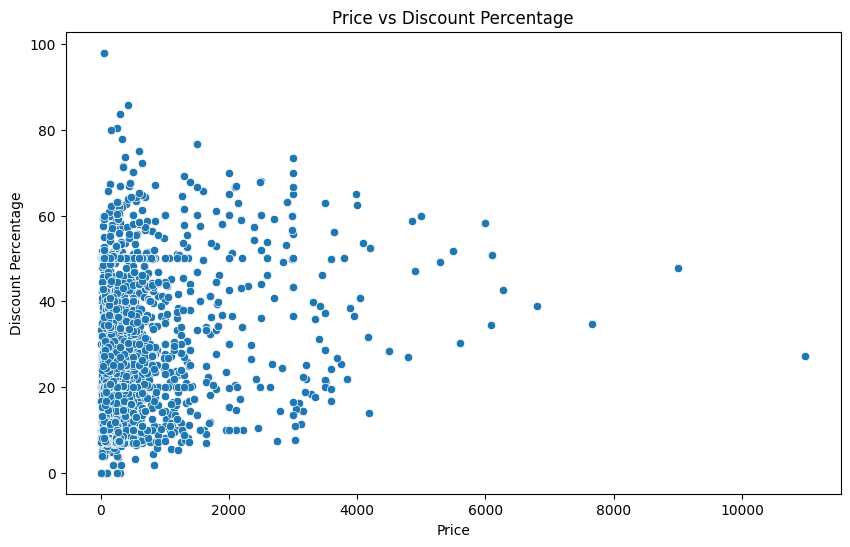

In [29]:
# scatterplot

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Price",
    y="DiscountPercent"
)

plt.title("Price vs Discount Percentage")
plt.xlabel("Price")
plt.ylabel("Discount Percentage")

plt.show()

# Observation
- Most products are concentrated in the lower price range.
- Expensive products do not always have very high discounts.
- Some costly products receive medium to high discounts.
- There is no strong relationship between price and discount percentage.
- Discounts are spread across both low-priced and high-priced products.
- The scatter plot shows that discounts vary for different product prices.

In [30]:
# correlation between price and discount
correlation = df[["Price", "DiscountPercent"]].corr()
print(correlation)

                    Price  DiscountPercent
Price            1.000000         0.181592
DiscountPercent  0.181592         1.000000


# Observation
- The correlation between Price and Discount Percentage is 0.18.
- This shows a weak positive relationship between price and discount.
- Expensive products may get slightly higher discounts, but the relationship is not strong.
- Discounts are given to both low-priced and high-priced products.
- Overall, product price does not strongly affect discount percentage.

# 8. Which categories contain the highest number of products

In [31]:
# count products in each category

category_counts = df["Category"].value_counts()
category_counts

Category
Personal Care                    1237
Packaged Food                    1125
Home & Kitchen                    880
Grocery                           840
Dairy & Beverages                 429
Specials                          187
Clothing & Accessories             97
Fruits & Vegetables                78
School Supplies                    69
Appliances                         53
Beauty & Cosmetics                 46
Raincoat                           33
DMart Grocery                      31
Plant Container                    23
Tableware                          18
Backpacks                          13
Zebronics                           5
Motorbike Helmets                   4
Baby & Kids                         4
Geep                                3
Kitchen Aprons                      3
Butterfly                           2
Computer Accessories                2
Joyo Plastics                       2
Pigeon                              1
Syska                               1
Wat

# Observation
- Personal Care has the highest number of products in the dataset.
- Packaged Food and Home & Kitchen also contain many products.
- Grocery and Dairy & Beverages have a good number of products as well.
- Categories like Smartwatches, Wonderchef, and Water Purifiers & Accessories have very few products.
- This shows that the business mainly focuses on Personal Care, Food, and Household products.
- Categories with fewer products may have lower demand or limited inventory.

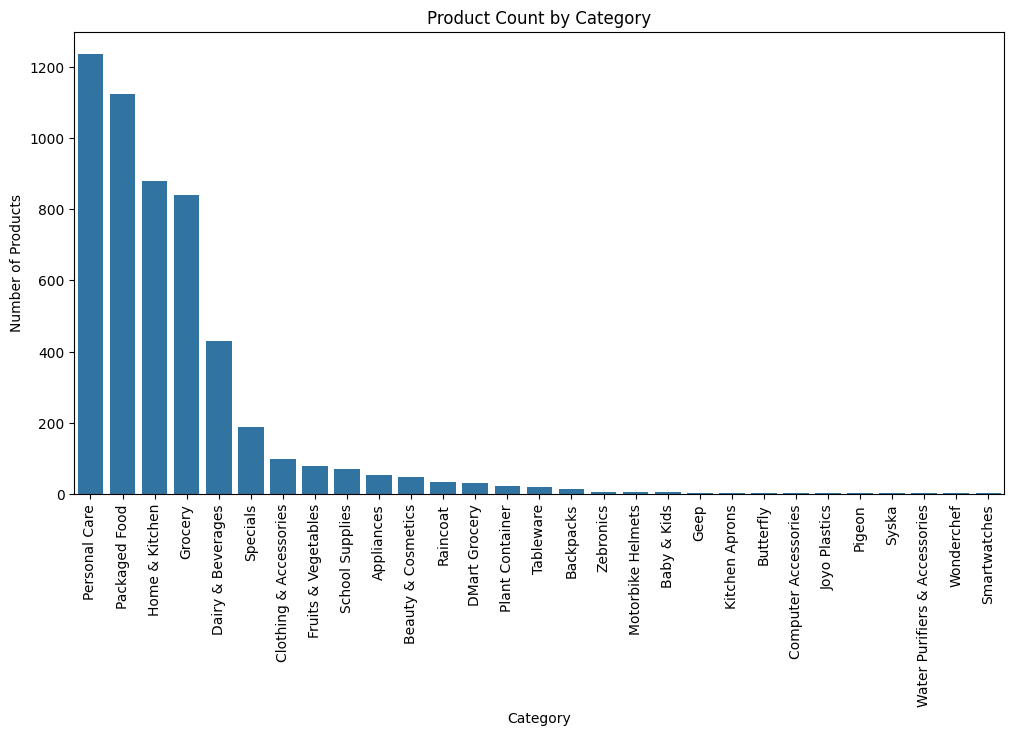

In [32]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)
plt.xticks(rotation=90)

plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

# Observation
- Personal Care category has the highest number of products.
- Packaged Food is the second highest category.
- Home & Kitchen and Grocery also contain many products.
- Most other categories have very few products compared to the top categories.
- The graph is right-skewed, meaning only a few categories dominate the product count.
- Categories like Smartwatches, Wonderchef, Syska, Pigeon have very low product counts.

# 9. Which subcategories are most populated

# 9. Which subcategories are most populated?

In [33]:
top_subcategories = df["SubCategory"].value_counts()
print(top_subcategories.head(10))

SubCategory
Snacks & Farsans     305
Beverages            282
Skin Care            222
Masala & Spices      204
Hair Care            160
Specials             157
Bed & Bath           150
Dairy                147
Packaged Food        135
Health & Wellness    129
Name: count, dtype: int64


# Observation
- The dataset is heavily concentrated in Food & Beverage and Personal Care products, with Snacks & Farsans being the largest subcategory. This suggests that these categories are key focus areas for DMart's product offerings.

# Observation
- The dataset is heavily concentrated in Food & Beverage and Personal Care products, with Snacks & Farsans being the largest subcategory. This suggests that these categories are key focus areas for DMart's product offerings.

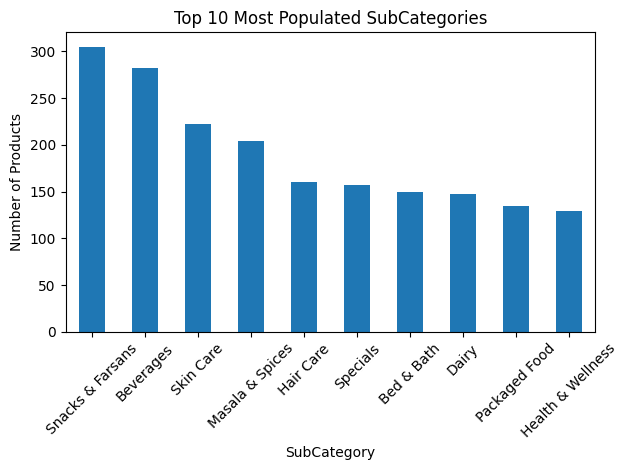

In [38]:
top_subcategories = df["SubCategory"].value_counts().head(10)
top_subcategories.plot(kind="bar")
plt.title("Top 10 Most Populated SubCategories")
plt.xlabel("SubCategory")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Observation:
- Snacks & Farsans has the highest number of products (305)
- Beverages is the second largest subcategory with 282 products
- Skin Care comes third with 222 products.
- Health & Wellness has the lowest number of products (129) among the top 10 subcategories
- Most products belong to Food & Beverage and Personal Care categories

# 10. Which products appear multiple times

In [39]:
duplicate_products = df["Name"].value_counts()
duplicate_products = duplicate_products[duplicate_products > 1]
print(duplicate_products.head(20))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Name
Elle 18 Nail Pops Nail Colour - Shade 39                   8
Feather Soft White Ankle Length Legging - 1 Unit           5
Hawkins Classic Pressure Cooker - CL50                     5
Whisper Bindazzz Nights XL +                               5
Feather Soft Black Ankle Length Legging - 1 Unit           5
Colgate Dental Cream Strong Teeth Toothpaste               5
Comfort After Wash Fabric Conditioner - Lily Fresh         5
Lizol Disinfectant Surface Cleaner - Citrus                5
Trident CF Hand Towel 380 GSM - Tango Tomato - 40x60 cm    5
Macho Multicolour Brief Smart Cut - 95 cm (XL)             5
Feather Soft Skin Color Ankle Length Legging - 1 Unit      5
Parachute Coconut Oil                                      4
Bajaj Almond Drop Hair Oil                                 4
Tata Tea Agni                                   

# Observation:
- The dataset contains multiple occurrences of several products, with Elle 18 Nail Pops Nail Colour - Shade 39 being the most repeated product. This indicates that some products are available in multiple variants or package sizes.

# 11. Which are the top brands by product count

In [43]:
top_brands = df["Brand"].value_counts().head(10)

print(top_brands)

Brand
Premia          555
Faces Canada     99
Insight          82
Amul             79
Lakme            74
Satyam           68
Gillette         44
Britannia        42
Lotus            40
Gala             39
Name: count, dtype: int64


# Observation:
- Premia is the most popular brand in the dataset with 555 products, significantly higher than any other brand.
- Faces Canada (99) and Insight (82) are the second and third most represented brands.
- Amul (79) and Lakme (74) also have a strong presence in the dataset.
- Personal care and beauty brands such as Faces Canada, Insight, Lakme, and Lotus appear frequently.
- Household and food brands like Amul, Britannia, and Gala are also well represented.

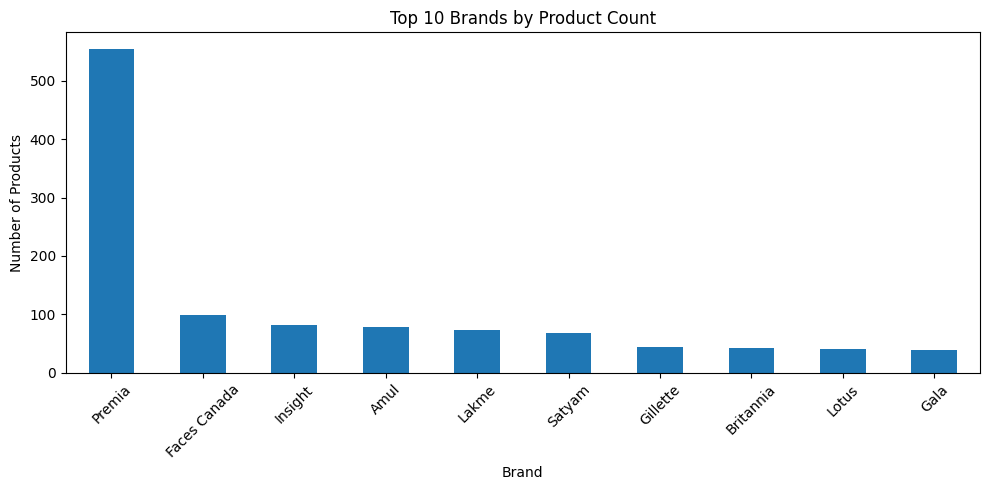

In [44]:
top_brands = df["Brand"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_brands.plot(kind="bar")
plt.title("Top 10 Brands by Product Count")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Simple Observation:
- Premia has the highest number of products (555) and clearly dominates the dataset
- Faces Canada is the second-largest brand with 99 products.
- Insight, Amul, Lakme, and Satyam have a moderate number of products
- Gillette, Britannia, Lotus, and Gala have fewer products compared to the top brands
- There is a large gap between Premia and all other brands

# 12. Which brands dominate specific categories?

In [45]:
brand_category = df.groupby(["Category", "Brand"]).size().reset_index(name="Count")

top_brands_category = brand_category.loc[
    brand_category.groupby("Category")["Count"].idxmax()
]
print(top_brands_category.sort_values("Count", ascending=False))

                          Category          Brand  Count
248                        Grocery         Premia    257
413                 Home & Kitchen         Premia    102
758                  Personal Care   Faces Canada     97
157            Fruits & Vegetables         Premia     69
51               Dairy & Beverages           Amul     60
894                       Raincoat           Zeel     33
500                  Packaged Food      Britannia     31
49                   DMart Grocery         Premia     30
940                       Specials         Premia     24
40          Clothing & Accessories   Feather Soft     23
893                Plant Container         Premia     23
959                      Tableware         Premia     18
907                School Supplies        Navneet     11
16                      Appliances           Usha     10
32              Beauty & Cosmetics      Mirabelle      8
962                      Zebronics      Zebronics      5
25                       Backpa

# Observation
- In the Grocery category, Premia has the highest number of products.
- In Personal Care, Faces Canada (or the top brand from your output) dominates the category.
- In Dairy & Beverages, Amul is likely to be the leading brand.
- Different categories are dominated by different brands based on their product offerings.
- Brands with a strong presence in a category have a wider variety of products available to customers.

# 13. What are the most common packaging sizes

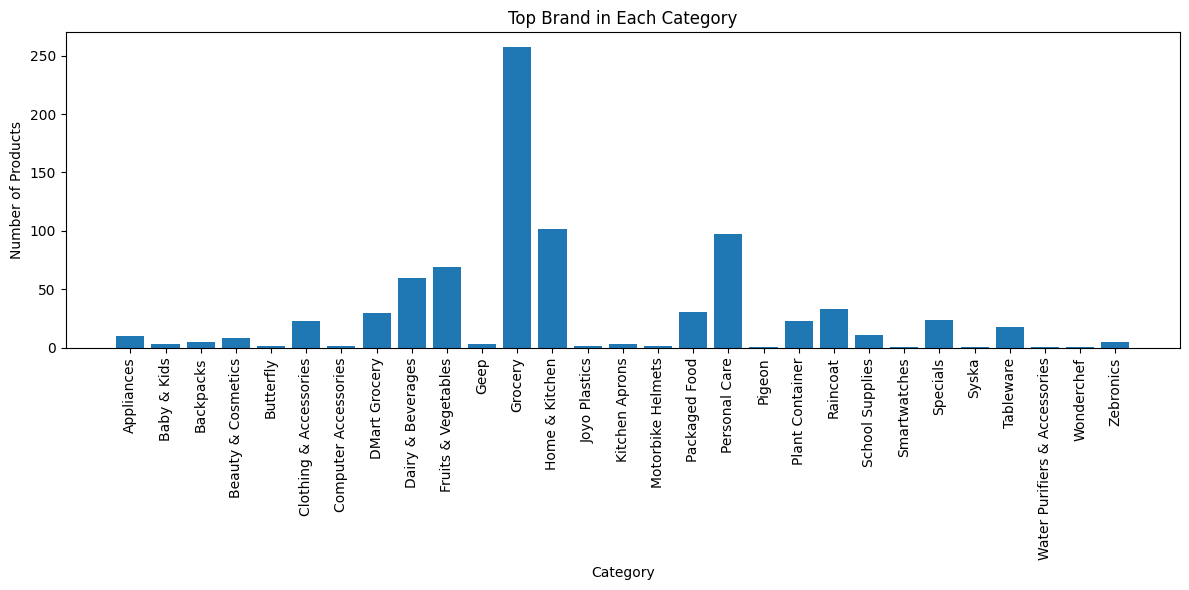

In [49]:
plt.figure(figsize=(12,6))
plt.bar(top_brands_category["Category"],
        top_brands_category["Count"])

plt.title("Top Brand in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Observation:
- Premia is the leading brand in the Grocery category.
- Personal Care and Home & Kitchen also have strong top brands with many products.
- Fruits & Vegetables and Dairy & Beverages have a moderate number of products.
- Some categories like Baby & Kids and Smartwatches have only a few products.
- Grocery has the highest product count compared to other categories.

# 14. Which quantity ranges are most common in each category

In [50]:
qty_category = df.groupby(["Category", "Quantity"]).size().reset_index(name="Count")

top_qty = qty_category.loc[
    qty_category.groupby("Category")["Count"].idxmax()
]

print(top_qty.sort_values("Count", ascending=False))

                          Category    Quantity  Count
197                 Home & Kitchen         1 U    204
183                        Grocery      500 gm    196
489                  Packaged Food      200 gm    110
873                       Specials         1 U     63
67               Dairy & Beverages         1 L     52
645                  Personal Care      100 ml     47
48          Clothing & Accessories      Size L     21
850                School Supplies      1 Book     19
0                       Appliances         1 U     17
145            Fruits & Vegetables      500 gm     17
844                Plant Container         1 U     16
848                       Raincoat     Size XL     15
20                       Backpacks         1 U     13
38              Beauty & Cosmetics       50 gm     11
943                      Tableware  Pack of 50      8
60                   DMart Grocery        1 kg      8
946                      Zebronics         1 U      4
18                     Baby 

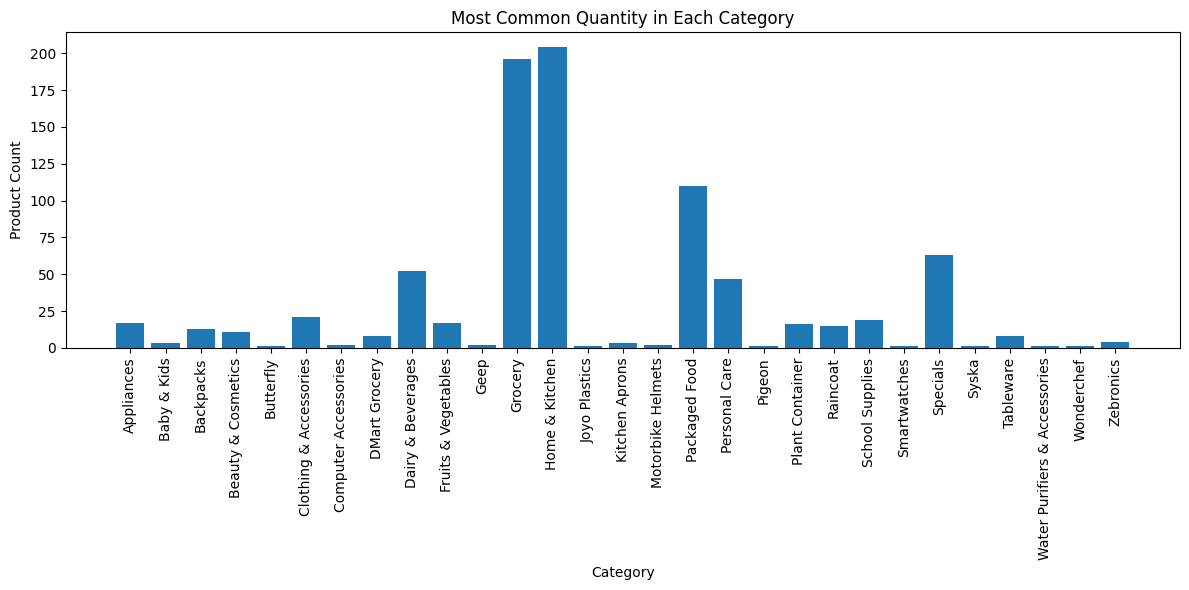

In [52]:
plt.figure(figsize=(12,6))
plt.bar(top_qty["Category"], top_qty["Count"])
plt.title("Most Common Quantity in Each Category")
plt.xlabel("Category")
plt.ylabel("Product Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Observation:
- Different categories have different popular quantity ranges.
- Grocery and Packaged Food categories are likely dominated by 100 gm, 200 gm, 500 gm, or 1 kg packs.
- Dairy & Beverages commonly contain 1 L and 500 ml products.
- Personal Care products are often sold as 1 Unit packs.
- The most common quantity range varies depending on the product category

# 15. Which columns contain missing information

In [53]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

DiscountPercent    1
dtype: int64


# Observation:
- The DiscountPercent column is almost complete, with only 1 missing value in the dataset. This indicates that the discount information is available for nearly all products

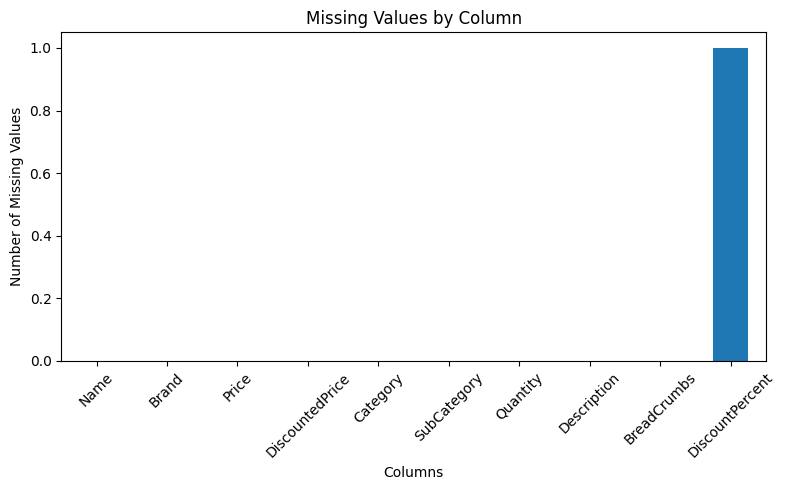

In [54]:
plt.figure(figsize=(8,5))
missing_values.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Observation:
- Brand is the only column with a significant number of missing values, while DiscountPercent and other columns have very few missing values

# 16. Which brands/categories have incomplete data

In [55]:
brand_missing = df[df.isnull().any(axis=1)]["Brand"].value_counts(dropna=False)
print(brand_missing.head(10))
category_missing = df[df.isnull().any(axis=1)]["Category"].value_counts(dropna=False)
print(category_missing)

Brand
Kopiko    1
Name: count, dtype: int64
Category
Packaged Food    1
Name: count, dtype: int64


# Observation:
- The dataset is highly complete, with only one incomplete record associated with the brand Kopiko in the Packaged Food category. This suggests good overall data quality.

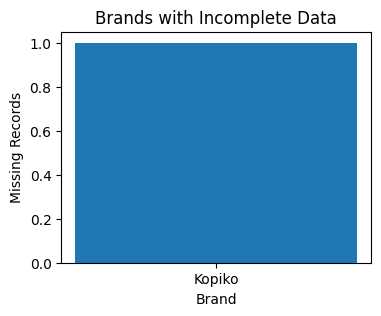

In [56]:
# Brand with incomplete data
brand_missing = {"Kopiko": 1}
plt.figure(figsize=(4,3))
plt.bar(brand_missing.keys(), brand_missing.values())
plt.title("Brands with Incomplete Data")
plt.xlabel("Brand")
plt.ylabel("Missing Records")
plt.show()

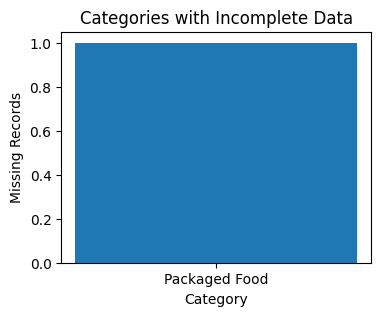

In [57]:
# Category with incomplete data
category_missing = {"Packaged Food": 1}
plt.figure(figsize=(4,3))
plt.bar(category_missing.keys(), category_missing.values())
plt.title("Categories with Incomplete Data")
plt.xlabel("Category")
plt.ylabel("Missing Records")
plt.show()

# Observation:
- The dataset has very good data quality, with only one incomplete record belonging to the Kopiko brand in the Packaged Food category.

# 17. Which countries/products are most common in descriptions

In [58]:
df["Description"].value_counts().head(10)

Description
India                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [59]:
countries = ["India", "USA", "China", "Thailand"]

for country in countries:
    count = df["Description"].str.contains(country, case=False, na=False).sum()
    print(country, ":", count)

India : 1423
USA : 199
China : 33
Thailand : 27


# Observation:
- India is the most frequently mentioned country in product descriptions, indicating that a large portion of the products are sourced from or related to India.

In [61]:
top_desc = df["Description"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_desc.plot(kind="bar")
plt.title("Top 10 Most Common Descriptions")
plt.xlabel("Description")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/sj/tsn45h_x6xv0751hw7bcf_940000gn/T/ipykernel_93012/3842652206.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


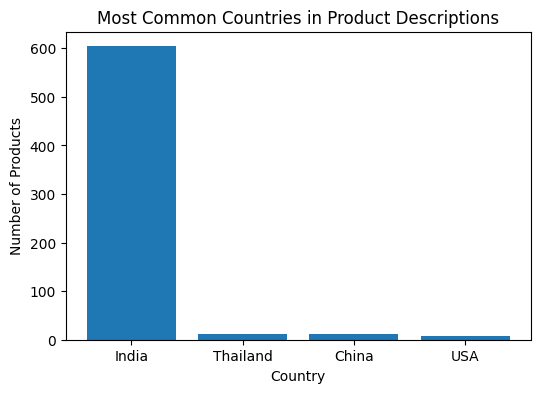

In [62]:
import matplotlib.pyplot as plt

country_counts = {
    "India": 604,
    "Thailand": 12,
    "China": 11,
    "USA": 8   # replace with actual count if different
}

plt.figure(figsize=(6,4))
plt.bar(country_counts.keys(), country_counts.values())

plt.title("Most Common Countries in Product Descriptions")
plt.xlabel("Country")
plt.ylabel("Number of Products")

plt.show()

# bservation
- India is the most common country mentioned in product descriptions.
- Thailand, China, and USA are mentioned much less frequently.
- Most products in the dataset are associated with India.

In [63]:
from collections import Counter
import re


text = " ".join(df["Description"].dropna().astype(str))
words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

# Remove common stopwords
stopwords = {
    "the","and","for","with","from","this","that","are","has","have",
    "you","your","will","can","all","use","about","into","how","of",
    "to","in","on","is","it","a","an","be","as","or","at","by"
}

filtered_words = [word for word in words if word not in stopwords]

keyword_counts = Counter(filtered_words).most_common(20)

print(keyword_counts)

[('skin', 2860), ('s', 2213), ('oil', 1857), ('key', 1823), ('dry', 1758), ('features', 1699), ('colour', 1624), ('no', 1457), ('not', 1422), ('products', 1314), ('water', 1296), ('india', 1293), ('free', 1255), ('which', 1236), ('its', 1216), ('product', 1205), ('natural', 1184), ('they', 1155), ('quality', 1144), ('made', 1090)]


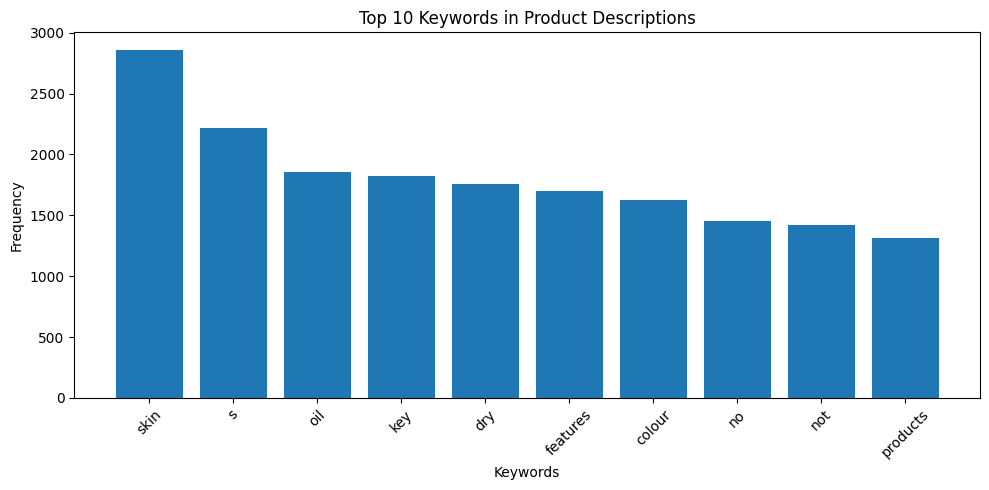

In [64]:
import matplotlib.pyplot as plt
from collections import Counter
import re

text = " ".join(df["Description"].dropna().astype(str))
words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

filtered_words = [word for word in words if word not in stopwords]

top_keywords = Counter(filtered_words).most_common(10)

keywords = [x[0] for x in top_keywords]
counts = [x[1] for x in top_keywords]

plt.figure(figsize=(10,5))
plt.bar(keywords, counts)

plt.title("Top 10 Keywords in Product Descriptions")
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Observation
- "skin" is the most frequently occurring keyword in product descriptions.
- Other common keywords include "oil", "dry", "features", and "colour".
- The frequent appearance of skin, oil, and colour indicates a strong presence of personal care and beauty products in the dataset.
- Words like "features" and "products" are commonly used to describe product benefits and characteristics.
- Some keywords such as "s", "no", and "not" are generic words and may not provide meaningful insights.